# 중고차 가격 예측 모델

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [5]:
car_df = pd.read_csv('../data/Dubizzle_used_car_sales.csv')
car_df.head()

,title,price_in_aed,kilometers,body_condition,mechanical_condition,seller_type,body_type,no_of_cylinders,transmission_type,regional_specs,horsepower,fuel_type,steering_side,year,color,emirate,motors_trim,company,model,date_posted
0,MITSUBISHI PAJERO 3.5L / 2013,26000,167390,Perfect inside and out,Perfect inside and out,Dealer,SUV,6,Automatic Transmission,GCC Specs,Unknown,Gasoline,Left Hand Side,2013.0,Silver,Dubai,GLS,mitsubishi,pajero,13/05/2022
1,chevrolet silverado,110000,39000,Perfect inside and out,Perfect inside and out,Dealer,SUV,8,Automatic Transmission,North American Specs,400 - 500 HP,Gasoline,Left Hand Side,2018.0,White,Sharjah,1500 High Country,chevrolet,silverado,14/01/2022
2,MERCEDES-BENZ E300 - 2014 - GCC SPEC - FULL OP...,78000,200000,Perfect inside and out,Perfect inside and out,Dealer,Sedan,6,Automatic Transmission,GCC Specs,400 - 500 HP,Gasoline,Left Hand Side,2014.0,Blue,Sharjah,E 300,mercedes-benz,e-class,05/05/2022
3,WARRANTY UNTIL APR 2023 || Ferrari 488 Spider ...,899000,27000,Perfect inside and out,Perfect inside and out,Dealer,Hard Top Convertible,8,Automatic Transmission,GCC Specs,600 - 700 HP,Gasoline,Left Hand Side,2018.0,Red,Dubai,Standard,ferrari,488-spider,30/04/2022
4,USED RENAULT DOKKER 2020,33000,69000,Perfect inside and out,Perfect inside and out,Owner,Wagon,4,Manual Transmission,GCC Specs,Less than 150 HP,Gasoline,Left Hand Side,2020.0,White,Dubai,Standard,renault,dokker,13/05/2022


In [6]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 9965 non-null   object 
 1   price_in_aed          9970 non-null   int64  
 2   kilometers            9970 non-null   int64  
 3   body_condition        9970 non-null   object 
 4   mechanical_condition  9970 non-null   object 
 5   seller_type           9970 non-null   object 
 6   body_type             9970 non-null   object 
 7   no_of_cylinders       9889 non-null   object 
 8   transmission_type     9970 non-null   object 
 9   regional_specs        9970 non-null   object 
 10  horsepower            9970 non-null   object 
 11  fuel_type             9970 non-null   object 
 12  steering_side         9970 non-null   object 
 13  year                  9000 non-null   float64
 14  color                 9970 non-null   object 
 15  emirate              

In [7]:
car_df.isnull().sum()

title                     5
price_in_aed              0
kilometers                0
body_condition            0
mechanical_condition      0
seller_type               0
body_type                 0
no_of_cylinders          81
transmission_type         0
regional_specs            0
horsepower                0
fuel_type                 0
steering_side             0
year                    970
color                     0
emirate                   0
motors_trim              28
company                   0
model                     0
date_posted               0
dtype: int64

+ 'title' 컬럼에 결측치가 5개 존재한다
+ 'no_of_cylinders' 컬럼에 결측치가 81개 존재한다
+ 'year' 컬럼에 결측치가 970개 존재한다
+ 'motors_trim' 컬럼에 결측치가 28개 존재한다

# 전처리

## 결측치 처리

In [8]:
car_df = car_df.drop('title', axis=1)   # title컬럼 삭제

In [9]:
car_df['no_of_cylinders'].value_counts()   # no_of_cylinders 컬럼의 값들 보기

no_of_cylinders
6          3325
4          2993
8          2986
12          366
Unknown      57
3            56
10           53
5            53
Name: count, dtype: int64

In [10]:
# no_of_cylinders 컬럼의 문자열(Unknown) 제거 및 숫자형으로 변환
car_df['no_of_cylinders'] = pd.to_numeric(car_df['no_of_cylinders'].str.replace(' Cylinders', ''), errors='coerce')
# 최빈값(6)으로 대체
mode_cylinders = car_df['no_of_cylinders'].mode()[0]
car_df['no_of_cylinders'].fillna(mode_cylinders, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\3756518870.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_df['no_of_cylinders'].fillna(mode_cylinders, inplace=True)


In [11]:
# year의 결측치는 중앙값(median)으로 처리
car_df['year'].fillna(car_df['year'].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\2429507784.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_df['year'].fillna(car_df['year'].median(), inplace=True)


In [12]:
car_df['motors_trim'].value_counts()   # motors_trim 컬럼의 값들 보기

motors_trim
Other              2175
Standard            432
SE                  232
S                   227
G 63 AMG            197
                   ... 
LTS                   1
SHO                   1
CLK 350               1
Limited Edition       1
SLC 200               1
Name: count, Length: 856, dtype: int64

In [13]:
# motors_trim의 결측치는 최빈값(Other)로 처리
car_df['motors_trim'].fillna(car_df['motors_trim'].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\1053453839.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_df['motors_trim'].fillna(car_df['motors_trim'].mode()[0], inplace=True)


In [14]:
car_df.isnull().count()   # 결측치 모두 처리되었음

price_in_aed            9970
kilometers              9970
body_condition          9970
mechanical_condition    9970
seller_type             9970
body_type               9970
no_of_cylinders         9970
transmission_type       9970
regional_specs          9970
horsepower              9970
fuel_type               9970
steering_side           9970
year                    9970
color                   9970
emirate                 9970
motors_trim             9970
company                 9970
model                   9970
date_posted             9970
dtype: int64

## 범주형 처리

In [15]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_in_aed          9970 non-null   int64  
 1   kilometers            9970 non-null   int64  
 2   body_condition        9970 non-null   object 
 3   mechanical_condition  9970 non-null   object 
 4   seller_type           9970 non-null   object 
 5   body_type             9970 non-null   object 
 6   no_of_cylinders       9970 non-null   float64
 7   transmission_type     9970 non-null   object 
 8   regional_specs        9970 non-null   object 
 9   horsepower            9970 non-null   object 
 10  fuel_type             9970 non-null   object 
 11  steering_side         9970 non-null   object 
 12  year                  9970 non-null   float64
 13  color                 9970 non-null   object 
 14  emirate               9970 non-null   object 
 15  motors_trim          

In [16]:
# 모든 'object' 타입 컬럼을 가져옴
categorical_cols = car_df.select_dtypes(include='object').columns
print("--- 범주형 컬럼 분석 및 인코딩 전략 ---")

label_encode_candidates = [] # 레이블 인코딩 고려 컬럼
onehot_encode_candidates_small = [] # 원-핫 인코딩 적합 (고유값 적음)
onehot_encode_candidates_large = [] # 원-핫 인코딩 주의 (고유값 많음)
special_processing_needed = [] # 특별 처리 필요 (예: horsepower)

for col in categorical_cols:
    num_unique = car_df[col].nunique()
    print(f"컬럼: '{col}' | 고유값 개수: {num_unique}")

    if col in ['body_condition', 'mechanical_condition']:
        print(f"  -> 순서가 있을 수 있으므로 'Label Encoding' 또는 수동 매핑 고려.")
        label_encode_candidates.append(col)
    elif col == 'horsepower': # horsepower는 숫자 범위 문자열이므로 특별 처리
        print(f"  -> 마력 범위 문자열. 숫자형으로 변환 후 사용 고려.")
        special_processing_needed.append(col)
    elif col in ['company', 'model', 'motors_trim']:  # 이 컬럼들은 고유값이 많을 가능성
        if num_unique > 50: # 임의의 기준 (50개 초과면 많다고 판단)
            print(f"  -> 고유값이 많음 ({num_unique}개). 'One-Hot Encoding' 시 차원 증가 주의. 상위 N개 묶음 또는 타겟 인코딩 고려.")
            onehot_encode_candidates_large.append(col)
        else:
             print(f"  -> 순서 없음. 'One-Hot Encoding' 고려.")
             onehot_encode_candidates_small.append(col)
    elif num_unique <= 10: # 고유값 개수가 적은 경우 (임의의 기준: 10개 이하)
        print(f"  -> 순서 없음. 'One-Hot Encoding' 고려.")
        onehot_encode_candidates_small.append(col)
    else: # 고유값은 많지만, company/model만큼 많지 않을 경우 (예: regional_specs, emirate)
        print(f"  -> 순서 없음. 'One-Hot Encoding' 고려.")
        onehot_encode_candidates_small.append(col) # 10개 초과지만 너무 많지 않다고 가정. 필요시 large로 분류
    print("-" * 40)

print(f"\n✅ 레이블 인코딩 후보: {label_encode_candidates}")
print(f"✅ 원-핫 인코딩 (고유값 적음) 후보: {onehot_encode_candidates_small}")
print(f"⚠️ 원-핫 인코딩 (고유값 많음) 또는 특별 처리 후보: {onehot_encode_candidates_large}")
print(f"🛠️ 특별 숫자 변환 필요: {special_processing_needed}")

--- 범주형 컬럼 분석 및 인코딩 전략 ---
컬럼: 'body_condition' | 고유값 개수: 4
  -> 순서가 있을 수 있으므로 'Label Encoding' 또는 수동 매핑 고려.
----------------------------------------
컬럼: 'mechanical_condition' | 고유값 개수: 5
  -> 순서가 있을 수 있으므로 'Label Encoding' 또는 수동 매핑 고려.
----------------------------------------
컬럼: 'seller_type' | 고유값 개수: 3
  -> 순서 없음. 'One-Hot Encoding' 고려.
----------------------------------------
컬럼: 'body_type' | 고유값 개수: 13
  -> 순서 없음. 'One-Hot Encoding' 고려.
----------------------------------------
컬럼: 'transmission_type' | 고유값 개수: 2
  -> 순서 없음. 'One-Hot Encoding' 고려.
----------------------------------------
컬럼: 'regional_specs' | 고유값 개수: 5
  -> 순서 없음. 'One-Hot Encoding' 고려.
----------------------------------------
컬럼: 'horsepower' | 고유값 개수: 11
  -> 마력 범위 문자열. 숫자형으로 변환 후 사용 고려.
----------------------------------------
컬럼: 'fuel_type' | 고유값 개수: 4
  -> 순서 없음. 'One-Hot Encoding' 고려.
----------------------------------------
컬럼: 'steering_side' | 고유값 개수: 2
  -> 순서 없음. 'One-Hot Encoding' 고려.
-------------

In [17]:
# 'horsepower' 컬럼 처리: 숫자형으로 변환
def extract_avg_hp(hp_str):
    if isinstance(hp_str, str):
        hp_str = hp_str.replace(' HP', '').replace('+', '') # ' HP'와 '+' 제거
        if '-' in hp_str:
            parts = hp_str.split(' - ')
            try:
                return (float(parts[0]) + float(parts[1])) / 2
            except ValueError: # 변환 오류 시 NaN
                return np.nan
        else:
            try:
                return float(hp_str)
            except ValueError: # 변환 오류 시 NaN
                return np.nan
    return np.nan # 결측치 처리

car_df['horsepower_numeric'] = car_df['horsepower'].apply(extract_avg_hp)
# 변환 후 발생할 수 있는 결측치 처리 (평균으로 대체)
car_df['horsepower_numeric'].fillna(car_df['horsepower_numeric'].mean(), inplace=True)
car_df.drop('horsepower', axis=1, inplace=True) # 원본 horsepower 컬럼 삭제

print("--- 'horsepower' 변환 후 DataFrame 정보 ---")
car_df.info()
print("\n")

--- 'horsepower' 변환 후 DataFrame 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_in_aed          9970 non-null   int64  
 1   kilometers            9970 non-null   int64  
 2   body_condition        9970 non-null   object 
 3   mechanical_condition  9970 non-null   object 
 4   seller_type           9970 non-null   object 
 5   body_type             9970 non-null   object 
 6   no_of_cylinders       9970 non-null   float64
 7   transmission_type     9970 non-null   object 
 8   regional_specs        9970 non-null   object 
 9   fuel_type             9970 non-null   object 
 10  steering_side         9970 non-null   object 
 11  year                  9970 non-null   float64
 12  color                 9970 non-null   object 
 13  emirate               9970 non-null   object 
 14  motors_trim           9970 non-nu

C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\414413219.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_df['horsepower_numeric'].fillna(car_df['horsepower_numeric'].mean(), inplace=True)


In [18]:
# 'date_posted' 컬럼 처리: 날짜/시간 파생 변수 생성
car_df['date_posted'] = pd.to_datetime(car_df['date_posted'])
car_df['post_month'] = car_df['date_posted'].dt.month
car_df['post_dayofweek'] = car_df['date_posted'].dt.dayofweek
# car_df['post_year'] = car_df['date_posted'].dt.year # 연도는 'year' 컬럼과 겹칠 수 있으니 주의
car_df.drop('date_posted', axis=1, inplace=True) # 원본 날짜 컬럼 삭제

print("--- 'date_posted' 변환 후 DataFrame 정보 ---")
car_df.info()
print("\n")

--- 'date_posted' 변환 후 DataFrame 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_in_aed          9970 non-null   int64  
 1   kilometers            9970 non-null   int64  
 2   body_condition        9970 non-null   object 
 3   mechanical_condition  9970 non-null   object 
 4   seller_type           9970 non-null   object 
 5   body_type             9970 non-null   object 
 6   no_of_cylinders       9970 non-null   float64
 7   transmission_type     9970 non-null   object 
 8   regional_specs        9970 non-null   object 
 9   fuel_type             9970 non-null   object 
 10  steering_side         9970 non-null   object 
 11  year                  9970 non-null   float64
 12  color                 9970 non-null   object 
 13  emirate               9970 non-null   object 
 14  motors_trim           9970 non-n

C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\2829053338.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  car_df['date_posted'] = pd.to_datetime(car_df['date_posted'])


In [19]:
# 3. 범주형 컬럼 인코딩: 고유값 개수에 따라 전략 구분
# 현재 남아있는 'object' 타입 컬럼들 다시 확인
categorical_cols_for_encoding = car_df.select_dtypes(include='object').columns

# 고유값 개수 기준 정의
THRESHOLD_FOR_LARGE_CATEGORIES = 10 # 이 개수보다 많으면 '고유값 많음'으로 간주
TOP_N_CATEGORIES = 5 # '고유값 많음' 컬럼에서 상위 N개만 남기고 나머지는 'Other'로 묶을 개수

onehot_cols_to_process = [] # 원-핫 인코딩할 컬럼들

print("--- 최종 범주형 컬럼 인코딩 계획 ---")
for col in categorical_cols_for_encoding:
    num_unique = car_df[col].nunique()
    print(f"컬럼: '{col}' | 고유값 개수: {num_unique}")

    if num_unique <= THRESHOLD_FOR_LARGE_CATEGORIES:
        # 고유값이 적은 경우: 바로 원-핫 인코딩
        print(f"  -> 고유값 적음 ({num_unique}개). 'One-Hot Encoding' 적용.")
        onehot_cols_to_process.append(col)
    else:
        # 고유값이 많은 경우: 상위 N개만 남기고 'Other'로 묶은 후 원-핫 인코딩
        print(f"  -> 고유값 많음 ({num_unique}개). 상위 {TOP_N_CATEGORIES}개만 남기고 'Other'로 묶은 후 'One-Hot Encoding' 적용.")
        top_n_values = car_df[col].value_counts().nlargest(TOP_N_CATEGORIES).index
        car_df[col] = car_df[col].apply(lambda x: x if x in top_n_values else 'Other_' + col)
        onehot_cols_to_process.append(col) # 'Other'로 묶은 후에도 이 컬럼은 원-핫 인코딩 대상

    print("-" * 40)

--- 최종 범주형 컬럼 인코딩 계획 ---
컬럼: 'body_condition' | 고유값 개수: 4
  -> 고유값 적음 (4개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'mechanical_condition' | 고유값 개수: 5
  -> 고유값 적음 (5개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'seller_type' | 고유값 개수: 3
  -> 고유값 적음 (3개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'body_type' | 고유값 개수: 13
  -> 고유값 많음 (13개). 상위 5개만 남기고 'Other'로 묶은 후 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'transmission_type' | 고유값 개수: 2
  -> 고유값 적음 (2개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'regional_specs' | 고유값 개수: 5
  -> 고유값 적음 (5개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'fuel_type' | 고유값 개수: 4
  -> 고유값 적음 (4개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'steering_side' | 고유값 개수: 2
  -> 고유값 적음 (2개). 'One-Hot Encoding' 적용.
----------------------------------------
컬럼: 'color' | 고유값 개수: 17
  -> 고유값

In [20]:
# 최종적으로 한 번에 One-Hot Encoding 적용
print("\n--- One-Hot Encoding 적용 중... ---")
car_df = pd.get_dummies(car_df, columns=onehot_cols_to_process, drop_first=True, dtype=int) # dtype=int 추가하여 0/1 정수형으로 변환

print("\n--- 모든 전처리 후 DataFrame 정보 ---")
car_df.info()
print("\n--- 모든 전처리 후 DataFrame의 첫 5행 ---")
print(car_df.head())

# 모든 'object' 타입 컬럼이 사라졌는지 최종 확인
print("\n--- 전처리 후 남아있는 'object' 타입 컬럼 ---")
print(car_df.select_dtypes(include='object').columns)


--- One-Hot Encoding 적용 중... ---

--- 모든 전처리 후 DataFrame 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9970 entries, 0 to 9969
Data columns (total 55 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price_in_aed                                       9970 non-null   int64  
 1   kilometers                                         9970 non-null   int64  
 2   no_of_cylinders                                    9970 non-null   float64
 3   year                                               9970 non-null   float64
 4   horsepower_numeric                                 9970 non-null   float64
 5   post_month                                         9970 non-null   int32  
 6   post_dayofweek                                     9970 non-null   int32  
 7   body_condition_No accidents, very few faults       9970 non-null   int64  
 8   body_condition_Normal w

# 가격과 상관관계 시각화

In [21]:
# 'price_in_aed' 컬럼을 제외한 나머지 모든 컬럼과 상관관계 계산

# 이 단계에서는 숫자형 컬럼만 자동으로 선택됨 (boolean도 0/1로 계산됨)
correlation_with_price = car_df.corr(numeric_only=True)['price_in_aed'].sort_values(ascending=False)

# 'price_in_aed' 자기 자신과의 상관관계는 1이므로 제거
correlation_with_price = correlation_with_price.drop('price_in_aed')

print("--- 'price_in_aed'와의 상관관계 (내림차순 정렬) ---")
print(correlation_with_price)
print("\n")

--- 'price_in_aed'와의 상관관계 (내림차순 정렬) ---
horsepower_numeric                                   0.562578
no_of_cylinders                                      0.475022
model_g-class                                        0.234539
year                                                 0.205093
motors_trim_Standard                                 0.180716
motors_trim_Other                                    0.158588
emirate_ Dubai                                       0.147160
body_type_Other_body_type                            0.120126
company_mercedes-benz                                0.112775
regional_specs_Other                                 0.101203
fuel_type_Hybrid                                     0.084669
body_condition_Perfect inside and out                0.070503
mechanical_condition_Perfect inside and out          0.048426
color_Other_color                                    0.041819
body_type_SUV                                        0.036344
model_s-class                 

C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\3161259562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='viridis')


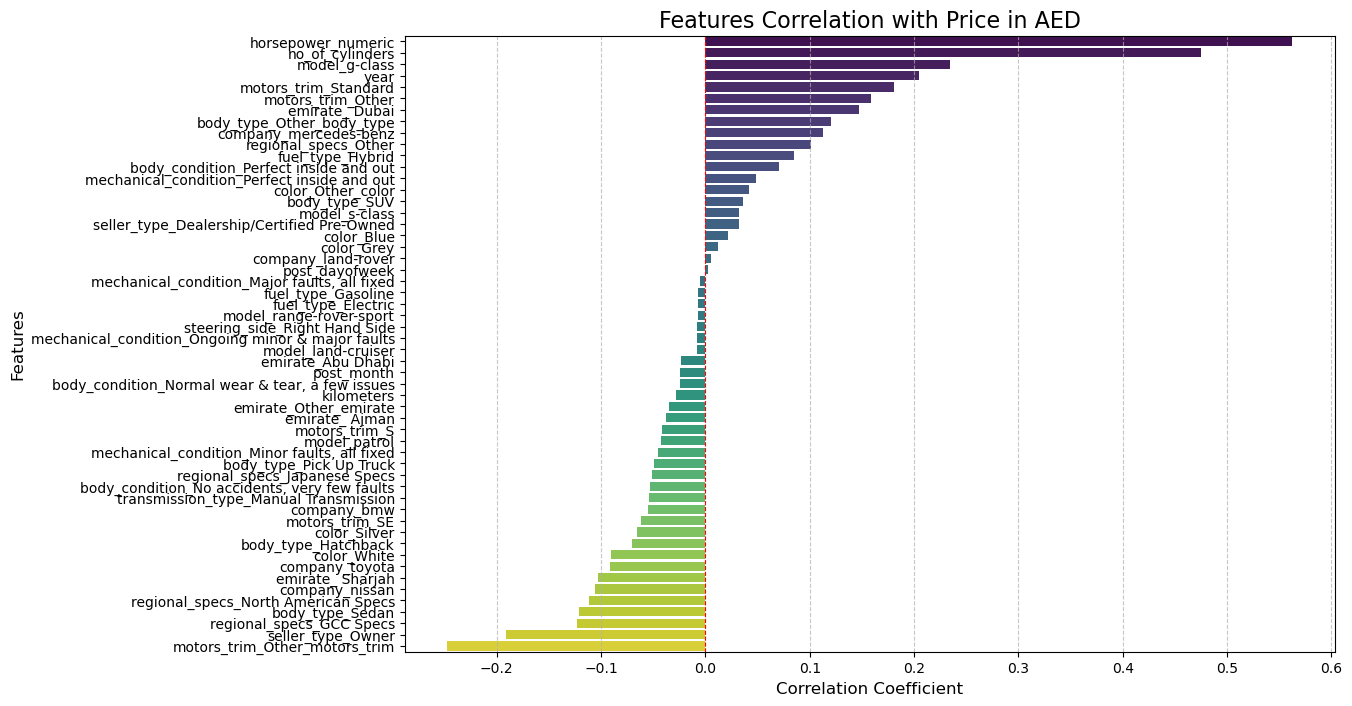

In [22]:
import seaborn as sns

plt.figure(figsize=(12, 8)) # 그래프 크기 설정
sns.barplot(x=correlation_with_price.values, y=correlation_with_price.index, palette='viridis')
plt.title('Features Correlation with Price in AED', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # x축에만 그리드 추가
plt.axvline(0, color='red', linestyle='--', linewidth=0.8) # 상관계수 0 기준선
plt.show()

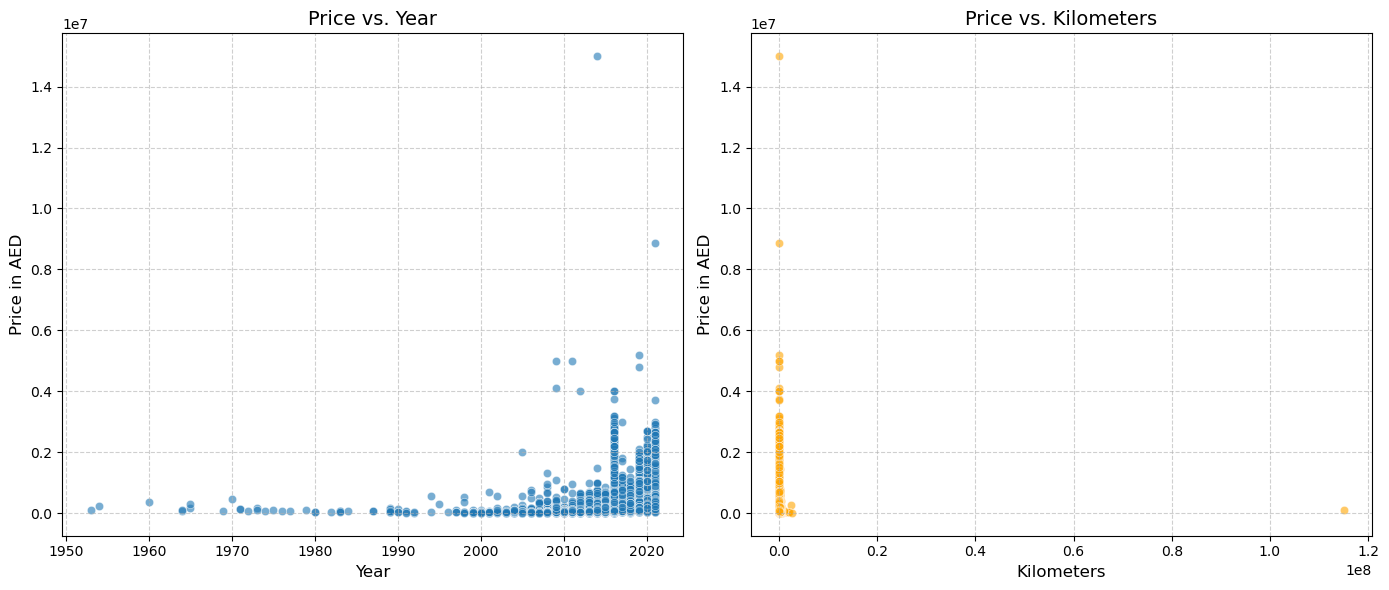

In [23]:
# 가격과 상관관계가 높은 상위 N개 피처 선택 (예: 상위 3개)
top_n_features = correlation_with_price.head(3).index.tolist() # 양의 상관관계 높은 것들
bottom_n_features = correlation_with_price.tail(2).index.tolist() # 음의 상관관계 높은 것들 (킬로미터 등)

# 예시로 2개 정도만 선택하여 산점도 그리기
# 'year' (양의 상관관계) 와 'kilometers' (음의 상관관계) 가 가장 일반적일 것입니다.
if 'year' in car_df.columns and 'kilometers' in car_df.columns:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
    sns.scatterplot(x='year', y='price_in_aed', data=car_df, alpha=0.6)
    plt.title('Price vs. Year', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Price in AED', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
    sns.scatterplot(x='kilometers', y='price_in_aed', data=car_df, alpha=0.6, color='orange')
    plt.title('Price vs. Kilometers', fontsize=14)
    plt.xlabel('Kilometers', fontsize=12)
    plt.ylabel('Price in AED', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout() # 서브플롯 간 간격 자동 조정
    plt.show()

<Axes: >

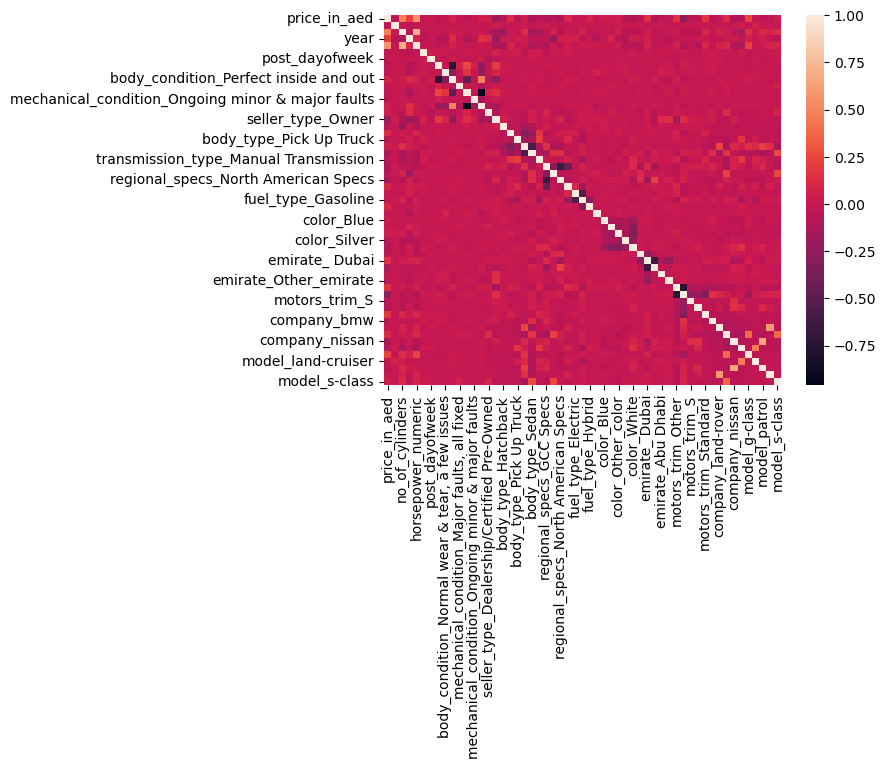

In [24]:
sns.heatmap(car_df.corr())

# 모델 만들기 (Linear Regression)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
# 타겟 변수 설정
y = car_df['price_in_aed']

# 피처 변수 설정 (타겟 변수를 제외한 모든 컬럼)
X = car_df.drop('price_in_aed', axis=1)

In [27]:
# 훈련 세트와 테스트 세트로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# 모델 생성
linear_model = LinearRegression()

# 모델 학습
linear_model.fit(X_train, y_train)

# 예측
y_pred_linear = linear_model.predict(X_test)

# 평가
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"선형 회귀 RMSE: {rmse_linear:.4f}")
print(f"선형 회귀 R2 Score: {r2_linear:.4f}")
print("-" * 40)

선형 회귀 RMSE: 420167.4030
선형 회귀 R2 Score: 0.3794
----------------------------------------


# 모델 만들기 (RandomForest Regression)

In [29]:
# 모델 생성
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1은 모든 코어 사용


In [30]:
# 모델 학습
random_forest_model.fit(X_train, y_train)

# 예측
y_pred_rf = random_forest_model.predict(X_test)

# 평가
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"랜덤 포레스트 RMSE: {rmse_rf:.2f}")
print(f"랜덤 포레스트 R2 Score: {r2_rf:.2f}")
print("-" * 40)

랜덤 포레스트 RMSE: 316272.54
랜덤 포레스트 R2 Score: 0.65
----------------------------------------


## 모델 성능 비교

In [31]:
print("\n--- 모델 성능 요약 ---")
print(f"선형 회귀 - RMSE: {rmse_linear:.2f}, R2 Score: {r2_linear:.2f}")
print(f"랜덤 포레스트 - RMSE: {rmse_rf:.2f}, R2 Score: {r2_rf:.2f}")



--- 모델 성능 요약 ---
선형 회귀 - RMSE: 420167.40, R2 Score: 0.38
랜덤 포레스트 - RMSE: 316272.54, R2 Score: 0.65


# 모델 만들기 (Linear Regresstion - Scaling 적용)

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [33]:
# 파이프라인 생성: 스케일링 -> 선형 회귀
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),       # 첫 번째 단계: StandardScaler
    ('regressor', LinearRegression())   # 두 번째 단계: LinearRegression 모델
])

In [34]:
# 파이프라인 학습 (X_train에 대해 scaler.fit_transform, regressor.fit 모두 수행)
pipeline_linear.fit(X_train, y_train)

# 예측 (X_test에 대해 scaler.transform, regressor.predict 모두 수행)
y_pred_scaled_linear = pipeline_linear.predict(X_test)

In [35]:
# 평가
rmse_scaled_linear = np.sqrt(mean_squared_error(y_test, y_pred_scaled_linear))
r2_scaled_linear = r2_score(y_test, y_pred_scaled_linear)

print(f"스케일링 선형 회귀 RMSE: {rmse_scaled_linear:.2f}")
print(f"스케일링 선형 회귀 R2 Score: {r2_scaled_linear:.2f}")
print("-" * 40)

스케일링 선형 회귀 RMSE: 420167.40
스케일링 선형 회귀 R2 Score: 0.38
----------------------------------------


# 모델 만들기 (RandomForest Regression - Scaling 적용)

In [36]:
# 파이프라인 생성: 스케일링 -> 랜덤 포레스트 회귀
# 랜덤 포레스트는 스케일에 덜 민감하지만, 일관성을 위해 적용
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

In [37]:
# 파이프라인 학습
pipeline_rf.fit(X_train, y_train)

# 예측
y_pred_scaled_rf = pipeline_rf.predict(X_test)

In [38]:
rmse_scaled_rf = np.sqrt(mean_squared_error(y_test, y_pred_scaled_rf))
r2_scaled_rf = r2_score(y_test, y_pred_scaled_rf)

print(f"스케일링 랜덤 포레스트 RMSE: {rmse_scaled_rf:.2f}")
print(f"스케일링 랜덤 포레스트 R2 Score: {r2_scaled_rf:.2f}")
print("-" * 40)

스케일링 랜덤 포레스트 RMSE: 317198.54
스케일링 랜덤 포레스트 R2 Score: 0.65
----------------------------------------


# 모델 만들기(Linear Regresstion - 교차 검증)

In [39]:
from sklearn.model_selection import KFold, cross_val_score

# KFold 설정 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [40]:
# scoring: 평가 지표. 'neg_root_mean_squared_error'는 RMSE의 음수 값 (cross_val_score는 점수를 최대화하므로 음수로 변환)
rmse_scores_linear_cv = -cross_val_score(pipeline_linear, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
r2_scores_linear_cv = cross_val_score(pipeline_linear, X_train, y_train, scoring='r2', cv=kf, n_jobs=-1)

print(f"교차 검증 선형 회귀 RMSE (각 폴드): {rmse_scores_linear_cv}")
print(f"교차 검증 선형 회귀 RMSE (평균): {rmse_scores_linear_cv.mean():.2f} (+/- {rmse_scores_linear_cv.std():.2f})")
print(f"교차 검증 선형 회귀 R2 Score (각 폴드): {r2_scores_linear_cv}")
print(f"교차 검증 선형 회귀 R2 Score (평균): {r2_scores_linear_cv.mean():.2f} (+/- {r2_scores_linear_cv.std():.2f})")
print("-" * 40)

교차 검증 선형 회귀 RMSE (각 폴드): [2.69641074e+05 2.80212102e+15 2.02755455e+06 3.59608082e+05
 1.08391988e+16]
교차 검증 선형 회귀 RMSE (평균): 2728263956422320.00 (+/- 4198166050530412.00)
교차 검증 선형 회귀 R2 Score (각 폴드): [ 5.29998673e-01 -4.87079561e+19 -1.98904342e+01  4.36698418e-01
 -6.24722147e+20]
교차 검증 선형 회귀 R2 Score (평균): -134686020698933985280.00 (+/- 245743201560641110016.00)
----------------------------------------


# 모델 만들기(RandomForest Regresstion - 교차 검증)

In [41]:
rmse_scores_rf_cv = -cross_val_score(pipeline_rf, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
r2_scores_rf_cv = cross_val_score(pipeline_rf, X_train, y_train, scoring='r2', cv=kf, n_jobs=-1)

In [42]:
print(f"교차 검증 랜덤 포레스트 RMSE (각 폴드): {rmse_scores_rf_cv}")
print(f"교차 검증 랜덤 포레스트 RMSE (평균): {rmse_scores_rf_cv.mean():.2f} (+/- {rmse_scores_rf_cv.std():.2f})")
print(f"교차 검증 랜덤 포레스트 R2 Score (각 폴드): {r2_scores_rf_cv}")
print(f"교차 검증 랜덤 포레스트 R2 Score (평균): {r2_scores_rf_cv.mean():.2f} (+/- {r2_scores_rf_cv.std():.2f})")
print("-" * 40)

교차 검증 랜덤 포레스트 RMSE (각 폴드): [152651.71216678 163544.72635946 168307.6013335  246536.75149934
 169161.23346522]
교차 검증 랜덤 포레스트 RMSE (평균): 180040.40 (+/- 33763.97)
교차 검증 랜덤 포레스트 R2 Score (각 폴드): [0.84936346 0.83407982 0.85605061 0.73524424 0.8478422 ]
교차 검증 랜덤 포레스트 R2 Score (평균): 0.82 (+/- 0.05)
----------------------------------------


# 모델 만들기(XGBoost)

In [59]:
import xgboost as xgb
from xgboost import XGBRegressor

In [60]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# 스케일링
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [62]:
# train_data로 학습하고, eval_data로 성능을 모니터링하여 조기 종료
X_train_scaled, X_eval_scaled, y_train, y_eval = train_test_split(
    X_train_scaled_full, y_train_full, test_size=0.25, random_state=42 # 전체 훈련 세트의 25%를 검증 세트로 사용 (전체 데이터의 80% * 25% = 20%)
)

print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"X_eval_scaled.shape: {X_eval_scaled.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print("\n")

X_train_scaled.shape: (5982, 54)
X_eval_scaled.shape: (1994, 54)
X_test_scaled.shape: (1994, 54)




In [63]:
print("--- XGBoost Regressor (Early Stopping) 평가 ---")

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # 회귀 문제에 사용되는 목적 함수
    n_estimators=1000,            # 충분히 큰 값으로 설정 (조기 종료가 알아서 멈출 것임)
    learning_rate=0.05,           # 학습률 (하이퍼파라미터 튜닝 필요)
    max_depth=5,                  # 트리의 최대 깊이 (하이퍼파라미터 튜닝 필요)
    random_state=42,
    n_jobs=-1                     # 모든 코어 사용
)

--- XGBoost Regressor (Early Stopping) 평가 ---


In [64]:
# 조기 종료를 위한 eval_set 설정. 첫 번째 튜플이 훈련 세트, 두 번째가 검증 세트입니다.
eval_set_xgb = [(X_train_scaled, y_train), (X_eval_scaled, y_eval)]

xgb_model.fit(X_train_scaled, y_train,
              eval_set=eval_set_xgb,
              early_stopping_rounds=50, # 50번의 반복 동안 검증 성능 향상이 없으면 중단
              verbose=False,            # 학습 과정 출력 끄기 (True로 설정하면 반복마다 성능 출력)
              eval_metric='rmse'        # 조기 종료를 판단할 평가 지표 (회귀에서는 'rmse' 또는 'mae')
             )

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\xgboost\sklearn.py:793: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\xgboost\sklearn.py:793: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.05, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=1000,
             n_jobs=-1, num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [ ]:
# 최적의 트리 개수를 가진 모델로 예측
xgb_pred = xgb_model.predict(X_test_scaled)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R2 Score: {r2_xgb:.2f}")
print(f"XGBoost Best Iteration: {xgb_model.best_iteration}")
print("-" * 40) 


XGBoost RMSE: 329819.28
XGBoost R2 Score: 0.62
XGBoost Best Iteration: 187
----------------------------------------


# 모델 성능 종합 비교

In [70]:
# 결과를 저장할 딕셔너리
results = {
    'Model': [],
    'RMSE': [],
    'R2 Score': [],
    'Evaluation Method': []
}

# 선형 회귀 (단일 분할)
results['Model'].append('Linear Regression')
results['RMSE'].append(rmse_linear)
results['R2 Score'].append(r2_linear)
results['Evaluation Method'].append('Train/Test Split')

# 랜덤 포레스트 (단일 분할)
results['Model'].append('Random Forest')
results['RMSE'].append(rmse_rf)
results['R2 Score'].append(r2_rf)
results['Evaluation Method'].append('Train/Test Split')

# 스케일링 선형 회귀 (단일 분할)
results['Model'].append('Linear Regression (Scaled)')
results['RMSE'].append(rmse_scaled_linear)
results['R2 Score'].append(r2_scaled_linear)
results['Evaluation Method'].append('Train/Test Split')

# 스케일링 랜덤 포레스트 (단일 분할)
results['Model'].append('Random Forest (Scaled)')
results['RMSE'].append(rmse_scaled_rf)
results['R2 Score'].append(r2_scaled_rf)
results['Evaluation Method'].append('Train/Test Split')

# 교차 검증 선형 회귀 (평균)
results['Model'].append('Linear Regression (CV)')
results['RMSE'].append(rmse_scores_linear_cv.mean())
results['R2 Score'].append(r2_scores_linear_cv.mean())
results['Evaluation Method'].append('K-Fold Cross-Validation (Avg)')

# 교차 검증 랜덤 포레스트 (평균)
results['Model'].append('Random Forest (CV)')
results['RMSE'].append(rmse_scores_rf_cv.mean())
results['R2 Score'].append(r2_scores_rf_cv.mean())
results['Evaluation Method'].append('K-Fold Cross-Validation (Avg)')

# XGBoost
results['Model'].append('XGBoost')
results['RMSE'].append(rmse_xgb)
results['R2 Score'].append(r2_xgb)
results['Evaluation Method'].append('Train/Test Split (Early Stopping)') # 조기 종료를 사용했으니 명시

# 결과 DataFrame 생성
results_df = pd.DataFrame(results)

print("\n--- 최종 모델 성능 비교 ---")
print(results_df.round(2)) # .round(2)로 소수점 둘째 자리까지 반올림하여 출력


--- 최종 모델 성능 비교 ---
                        Model          RMSE      R2 Score  \
0           Linear Regression  4.201674e+05  3.800000e-01   
1               Random Forest  3.162725e+05  6.500000e-01   
2  Linear Regression (Scaled)  4.201674e+05  3.800000e-01   
3      Random Forest (Scaled)  3.171985e+05  6.500000e-01   
4      Linear Regression (CV)  2.728264e+15 -1.346860e+20   
5          Random Forest (CV)  1.800404e+05  8.200000e-01   
6                     XGBoost  3.298193e+05  6.200000e-01   

                   Evaluation Method  
0                   Train/Test Split  
1                   Train/Test Split  
2                   Train/Test Split  
3                   Train/Test Split  
4      K-Fold Cross-Validation (Avg)  
5      K-Fold Cross-Validation (Avg)  
6  Train/Test Split (Early Stopping)  


<br/>

---


<br/>

# [결론]  어떤 모델이 가장 성능이 좋은가 ? 

| Model                      | RMSE              | R2 Score          | Evaluation Method           |
|:---------------------------|:------------------|:------------------|:----------------------------|
| Linear Regression          | 4.201674e+05      | 3.800000e-01      | Train/Test Split            |
| Random Forest              | 3.162725e+05      | 6.500000e-01      | Train/Test Split            |
| Linear Regression (Scaled) | 4.201674e+05      | 3.800000e-01      | Train/Test Split            |
| Random Forest (Scaled)     | 3.171985e+05      | 6.500000e-01      | Train/Test Split            |
| Linear Regression (CV)     | 2.728264e+15      | -1.346860e+20     | K-Fold Cross-Validation (Avg) |
| Random Forest (CV)         | 1.800404e+05 🥇     | 8.200000e-01 🥇     | K-Fold Cross-Validation (Avg) |
| XGBoost                    | 3.298193e+05      | 6.200000e-01      | Train/Test Split (Early Stopping) |

모델 학습 및 평가 결과, 랜덤 포레스트 회귀 모델이 중고차 가격 예측에 있어 가장 우수한 성능을 보이는 것으로 확인되었습니다. 특히 **교차 검증을 통해 평가된 Random Forest (CV) 모델**은 RMSE 1.80e+05로 가장 낮은 오차를 기록했으며, R2 Score 0.82로 가장 높은 설명력을 보여주었습니다. 이는 모델이 중고차 가격의 변동성을 약 82% 설명할 수 있음을 의미하며, 실제 가격을 상당히 정확하게 예측하고 있음을 시사합니다.

<br>
반면, 선형 회귀 모델은 교차 검증 과정에서 비정상적으로 높은 RMSE와 매우 낮은 R2 Score를 기록하며 모델의 안정성 및 예측 능력에 심각한 문제가 있음을 드러냈습니다. 이는 선형 회귀 모델이 데이터 내의 복잡한 비선형 관계나 이상치에 취약하며, 이러한 특성을 고려하지 않고서는 안정적인 성능을 기대하기 어렵다는 것을 보여줍니다.

---
<br>

### 주요 발견 및 제언


+ **선형 회귀 모델의 한계 및 불안정성**: 선형 회귀 모델은 교차 검증 시 RMSE가 2.73e+15, R2 Score가 -1.35e+20와 같은 비정상적인 결과를 보였습니다. 이는 데이터 내의 심각한 이상치나 강한 비선형 관계가 선형 모델의 예측 안정성을 크게 저해했음을 의미합니다. 스케일링을 적용했음에도 이러한 현상이 나타난 점은 선형 모델이 본 데이터의 특성을 반영하는 데 근본적인 한계가 있음을 보여줍니다.

+ **랜덤 포레스트 모델의 하이퍼파라미터 튜닝**: 현재 기본 설정으로도 우수한 성능을 보였으므로, GridSearchCV 또는 RandomizedSearchCV를 활용하여 n_estimators, max_depth, min_samples_split 등 랜덤 포레스트의 하이퍼파라미터를 최적화한다면 예측 성능을 더욱 향상시킬 수 있을 것입니다.

----

### 결론 및 향후 계획


본 프로젝트는 중고차 데이터셋을 활용하여 가격 예측 모델을 구축하고 다양한 회귀 모델의 성능을 비교 분석했습니다. 데이터 스케일링, 범주형 데이터 인코딩 등의 전처리 과정을 거쳐 데이터를 모델 학습에 적합한 형태로 변환했습니다. 그 결과, 랜덤 포레스트 회귀 모델이 가장 견고하고 뛰어난 예측 성능을 입증하며 중고차 가격 예측을 위한 최적의 모델로 판단되었습니다. 이 모델은 중고차 시장의 복잡한 가격 형성 요인을 효과적으로 반영할 수 있음을 보여주었습니다.

<br>
향후 모델 개선을 위해서는 다음과 같은 방안을 고려해볼 수 있습니다:

+ **모델 성능 최적화**: 현재 선정된 랜덤 포레스트 모델에 대한 심층적인 하이퍼파라미터 튜닝을 수행하여 RMSE를 추가로 낮추고 R2 Score를 높이는 것을 목표로 합니다.

+ **모델 일반화 및 안정성 강화**: 선형 회귀 모델에서 나타난 불안정성 문제를 분석하고, 강력한 이상치 처리 기법 및 정규화 기법 적용을 통해 모델의 견고성을 확보할 수 있습니다. 더 나아가 XGBoost, LightGBM 등 다른 부스팅 계열 모델의 도입을 검토하여 예측 성능을 비교하고 최적의 모델을 탐색합니다.

+ **예측 불확실성 분석**: 단일 예측값 제공을 넘어, 특정 중고차에 대한 가격 예측 범위 또는 신뢰 구간을 제시하여 사용자에게 더 유용한 정보를 제공할 수 있도록 모델의 불확실성 분석 기능을 추가합니다.

------------
